# UK Water: How will it affect by the increase in Data centres 
### Who will be responsible for the increase in water demand for machine learning usages, ordinarly working class individuals or tech giants? 

#### **Section 1: UK water Cost & Consumption Trends**
- 1. The water costs trend (ONS data)
- 2. New approved price by Ofwat (Ofwat PR24)
- 3. Volume: UK daily water consumption (EA/Defra Data)

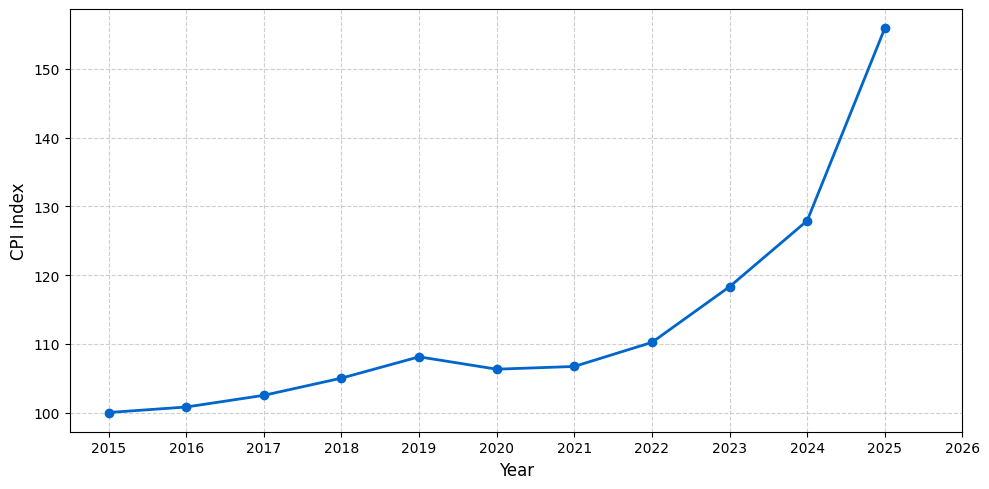

In [2]:
# Water supply CPI Index determine how much water supply costs have increased over time
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns   

csv_file = "series-020626-2.csv"
df= pd.read_csv(open(csv_file))


# 1. Slice the dataframe to keep only rows from index 7 onwards (the actual data)
df_clean = df.iloc[7:].copy()

# 2. Rename the columns to clean, professional names
df_clean.columns = ['Year', 'CPI Index']


# 1. Force both columns to be actual numbers (this fixes the overlapping axis mess)
df_clean['Year'] = pd.to_numeric(df_clean['Year'], errors='coerce')
df_clean['CPI Index'] = pd.to_numeric(df_clean['CPI Index'], errors='coerce')

# 2. Filter for only the years between 2015 and 2026
df_filtered = df_clean[(df_clean['Year'] >= 2015) & (df_clean['Year'] <= 2026)]

# 3. Sort by Year just in case the dataset rows are out of order (fixes the jumping lines)
df_filtered = df_filtered.sort_values('Year').reset_index(drop=True)

# 4. Plot the clean data
plt.figure(figsize=(10, 5))
plt.plot(df_filtered['Year'], df_filtered['CPI Index'], marker='o', linestyle='-', color='#0066cc', linewidth=2)

# Styling details for a professional look
plt.xlabel('Year', fontsize=12)
plt.ylabel('CPI Index', fontsize=12)

# Ensure the X-axis only shows clean, actual year numbers
plt.xticks(range(2015, 2027)) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



In [3]:
# Calculate year-on-year percentage increase
df_filtered['YoY_Increase_Pct'] = df_filtered['CPI Index'].pct_change() * 100

print("Historical ONS Water Tariff Index (Baseline 2015=100):")
print(df_filtered)

Historical ONS Water Tariff Index (Baseline 2015=100):
      Year  CPI Index  YoY_Increase_Pct
0   2015.0      100.0               NaN
1   2016.0      100.8          0.800000
2   2017.0      102.5          1.686508
3   2018.0      105.0          2.439024
4   2019.0      108.1          2.952381
5   2020.0      106.3         -1.665125
6   2021.0      106.7          0.376294
7   2022.0      110.2          3.280225
8   2023.0      118.3          7.350272
9   2024.0      127.9          8.114962
10  2025.0      155.9         21.892103


## PR24 
PR24 is a regulatory used to project how water companies are allowed to charge consumers in the upcoming years due to crisis including sewage leaks, climate change, and pre-existing water stress. 

This is used because the CPI index increased significantly from 2022 to 2025 comparing to the years before that (specifically 2015 to 2022). Consequently, PR24 will represent Ofwat new apprval price hikes. 

This is due to the increase in water demand and requirement for expansion of Capex for water infrastructure. 

In [5]:
import seaborn as sns

# --- STEP 1: DYNAMIC IMPORT FROM LOCAL XLSX ---
file_path = "England and Wales average water bills 1989 2025.xlsx"

# If the data doesn't start on Row 1, use 'header' to point to the row containing column names (0-indexed).
# For example, if row 4 has your headers: header=3. Let's assume standard formatting for now:
df_excel = pd.read_excel(file_path, sheet_name=1, header=0, engine="openpyxl")

# Ensure column names map perfectly to what we expect
# Based on your image, it looks like: Column A is Year, Column C is Real Bill (Nov 2024 prices)
# Let's cleanly subset and rename them for the model:
df_excel = df_excel.iloc[:, [0, 2]]  # Pull column 0 (A) and column 2 (C)
df_excel.columns = ["Year", "Avg_Bill_Real_GBP"]

# Filter for a modern 10-year baseline view (e.g., from 2015-16 to 2024-25)
# This keeps your notebook visualization clean and highly readable
# Select columns: Year (Col 0) and Average real bills (Col 2)
df_past = df_excel
# Filter for the modern historical timeline (last 10 years up to the transition)
target_years = ["2015-16", "2016-17", "2017-18", "2018-19", "2019-20", 
                "2020-21", "2021-22", "2022-23", "2023-24", "2024-25"]
df_past = df_past[df_past["Year"].isin(target_years)].reset_index(drop=True)
df_past["Type"] = "Historical Baseline"

print("--- Cleaned Historical Data ---")
print(df_past.head())


--- Cleaned Historical Data ---
      Year  Avg_Bill_Real_GBP                 Type
0  2024-25                480  Historical Baseline
1  2023-24                459  Historical Baseline
2  2022-23                451  Historical Baseline
3  2021-22                485  Historical Baseline
4  2020-21                506  Historical Baseline


This data is converetd in November 2024 pounds

In [7]:
# Create the PR24 DataFrame using the exact numbers from your uploaded screenshot
pr24_company_data = {
    "Company": [
        "Anglian Water", "Southern Water", "Thames Water", "Severn Trent Water", # Zone 1
        "Northumbrian Water", "United Utilities", "Yorkshire Water", "Dŵr Cymru"   # Zone 2
    ],
    "Zone": [
        "Zone 1 (Stressed)", "Zone 1 (Stressed)", "Zone 1 (Stressed)", "Zone 1 (Stressed)",
        "Zone 2 (Abundant)", "Zone 2 (Abundant)", "Zone 2 (Abundant)", "Zone 2 (Abundant)"
    ],
    "Bill_2024_25": [491, 420, 436, 398, 422, 442, 430, 455],
    "Bill_2029_30": [631, 642, 588, 583, 510, 585, 607, 645]
}

df_pr24 = pd.DataFrame(pr24_company_data)

# Group by Zone to get the average macro trajectory for each region
df_zone_projections = df_pr24.groupby("Zone")[["Bill_2024_25", "Bill_2029_30"]].mean().reset_index()

print("\n--- Macro Regional Baseline from PR24 Screenshot ---")
print(df_zone_projections)

# Generate a smooth year-by-year path from 2024 to 2030 based on your data
years_future = ["2024-25", "2025-26", "2026-27", "2027-28", "2028-29", "2029-30"]

future_tracks = []
for idx, row in df_zone_projections.iterrows():
    # Calculate a steady annual step increase
    start_val = row["Bill_2024_25"]
    end_val = row["Bill_2029_30"]
    step = (end_val - start_val) / 5
    
    for i, yr in enumerate(years_future):
        future_tracks.append({
            "Year": yr,
            "Avg_Bill_Real_GBP": start_val + (step * i),
            "Zone": row["Zone"],
            "Type": "PR24 Approved Baseline"
        })

df_future_timeline = pd.DataFrame(future_tracks)


--- Macro Regional Baseline from PR24 Screenshot ---
                Zone  Bill_2024_25  Bill_2029_30
0  Zone 1 (Stressed)        436.25        611.00
1  Zone 2 (Abundant)        437.25        586.75


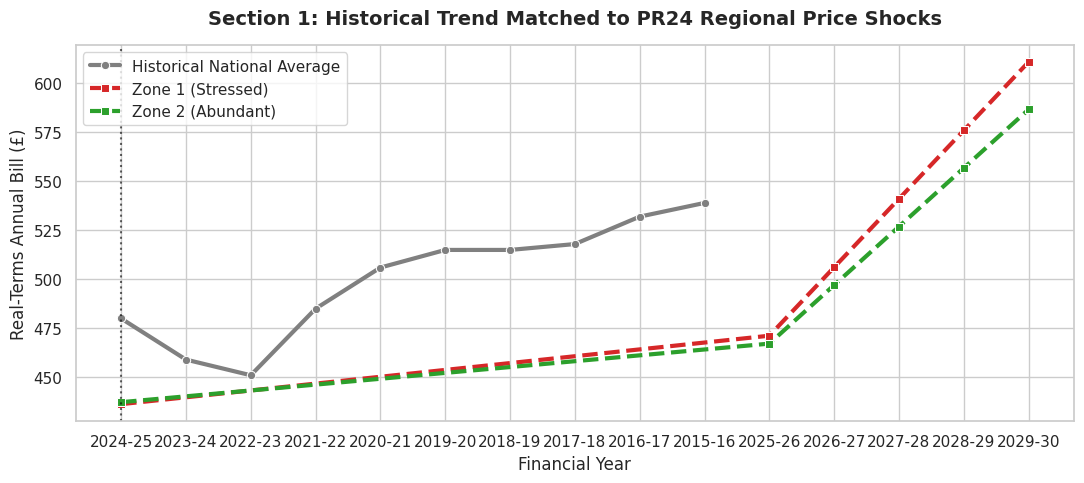

In [8]:
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

# 1. Plot the historical line from your Excel sheet
sns.lineplot(data=df_past, x="Year", y="Avg_Bill_Real_GBP", 
             color="gray", linewidth=3, label="Historical National Average", marker="o")

# 2. Plot the split future trajectories from your Ofwat screenshot
sns.lineplot(data=df_future_timeline, x="Year", y="Avg_Bill_Real_GBP", hue="Zone",
             linewidth=3, linestyle="--", marker="s", palette={"Zone 1 (Stressed)": "#d62728", "Zone 2 (Abundant)": "#2ca02c"})

plt.axvline(x="2024-25", color="black", linestyle=":", alpha=0.6)
plt.title("Section 1: Historical Trend Matched to PR24 Regional Price Shocks", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Financial Year", fontsize=12)
plt.ylabel("Real-Terms Annual Bill (£)", fontsize=12)
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()



In [ ]:
# --- STEP 3: BASELINE VOLUMETRIC DEMAND ---
# Establishing the national volumetric baseline in Megaliters per Day (MLd)

UK_BASELINE_DOMESTIC_DEMAND_MLD = 14000.0  # ~14 Billion Liters/Day
METRIC_CONVERSION_FACTOR = 365 # To get annual volumes

annual_baseline_liters = UK_BASELINE_DOMESTIC_DEMAND_MLD * 1_000_000 * METRIC_CONVERSION_FACTOR
print(f"\nBaseline National Public Water Demand: {UK_BASELINE_DOMESTIC_DEMAND_MLD} MLd")
print(f"Equivalent to standard baseline of: {annual_baseline_liters:,.0f} Liters per Year.")


Baseline National Public Water Demand: 14000.0 MLd
Equivalent to standard baseline of: 5,110,000,000,000 Liters per Year.


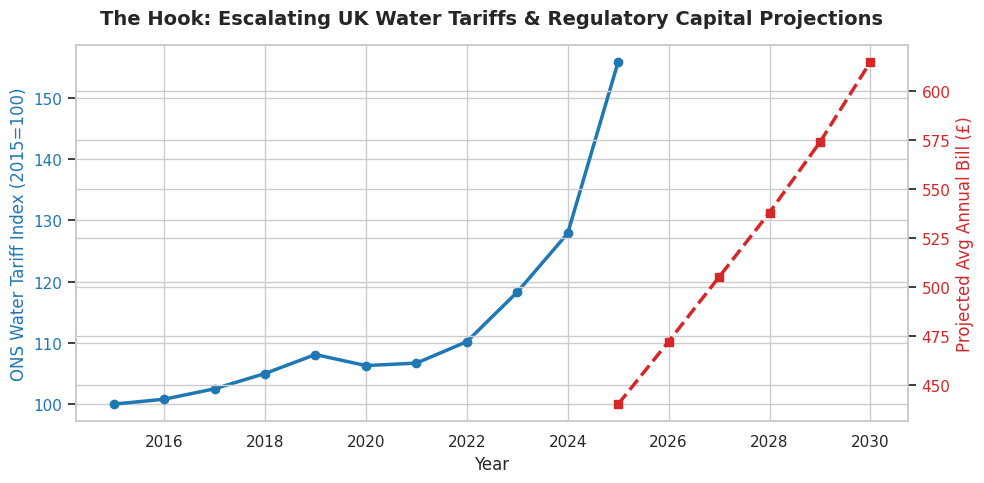

In [ ]:
# --- VISUALIZATION FUNCTION ---
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plotting historical Index
color = '#1f77b4'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('ONS Water Tariff Index (2015=100)', color=color, fontsize=12)
ax1.plot(df_filtered['Year'], df_filtered['CPI Index'], color=color, marker='o', linewidth=2.5, label='Historical Tariff Index')
ax1.tick_params(axis='y', labelcolor=color)

# Creating a second y-axis to plot the PR24 absolute bill projections forward
ax2 = ax1.twinx()  
color = '#d62728'
ax2.set_ylabel('Projected Avg Annual Bill (£)', color=color, fontsize=12)
ax2.plot(df_pr24['Year'], df_pr24['Projected_Avg_Bill_GBP'], color=color, linestyle='--', marker='s', linewidth=2.5, label='PR24 Core Projection')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('The Hook: Escalating UK Water Tariffs & Regulatory Capital Projections', fontsize=14, pad=15, fontweight='bold')
fig.tight_layout()
plt.show()